In [1]:
import os
import help
from help import prepare_dataset, test_on_data, plot_train_history, plot_confusion_matrix
# from help import vgg_model, resnet_model, swin_transformer_model, cv_train_model, cv_train_vgg_model
from help import vgg_model, resnet_model, cv_train_and_evaluate_model, train_and_evaluate_model, cv_train_model, cv_train_vgg_model, imbalanced_cv_train_and_evaluate_model



2024-12-28 11:40:14.962394: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-28 11:40:16.431719: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-28 11:40:16.431756: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-28 11:40:16.433772: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-28 11:40:17.035220: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-28 11:40:17.036471: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [2]:
help.sns.set_theme()
path_dir = help.os.getcwd()
help.np.random.seed(123)
help.tf.random.set_seed(123)


# Train on Selected Data

In [3]:
path_dir = r"/users/PCS0229/imankhazrak/DDPM_L/Classification"


In [4]:
dataset_dir_org = f'{path_dir}/10_percent/Original'
sorted(os.listdir(dataset_dir_org))

['Cyct',
 'Granuloma',
 'Keratosis',
 'Nodule',
 'Polyp',
 'Reinke’s Edema',
 'Sulcus Vocalis']

In [5]:
dataset_dir_org = f'{path_dir}/10_percent/Original'
dataset_dir_ddpm = f'{path_dir}/10_percent/Generated_CLEAN_1'

class_labels = sorted(os.listdir(dataset_dir_org))
# class_labels = ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']


print('class_labels: ', class_labels)
num_classes = len(class_labels)
print('Number of classes= ', num_classes)
input_shape=(128, 128, 3)

cv=1
epochs=40
batch_size=32
n = 1 # number of different runs

class_labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Number of classes=  7


In [6]:
import os

def remove_desktop_ini(root_dir):
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower() == "desktop.ini":
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    print(f"Removed: {file_path}")
                except Exception as e:
                    print(f"Error removing {file_path}: {e}")

# # Replace 'path_to_images' with the path to your image folders
# path_to_images = "path_to_your_image_folders"
# remove_desktop_ini(path_to_images)

dataset_dir_org = f'{path_dir}/Original'
dataset_dir_ddpm = f'{path_dir}/Generated_CLEAN_1'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)
dataset_dir_org = f'{path_dir}/10_percent/Original'
dataset_dir_ddpm = f'{path_dir}/10_percent/Generated_CLEAN_1'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)
dataset_dir_org = f'{path_dir}/50_percent/Original'
dataset_dir_ddpm = f'{path_dir}/50_percent/Generated_CLEAN_1'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)

## Untrained VGG16

#### Train on Syn test on Original Dataset

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']


2024-12-28 02:46:28.428576: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
95/95 [==============================] - 29s 299ms/step - loss: 2.0344 - accuracy: 0.2553 - val_loss: 1.7666 - val_accuracy: 0.3105
Epoch 2/100
95/95 [==============================] - 29s 304ms/step - loss: 1.7655 - accuracy: 0.3254 - val_loss: 1.6933 - val_accuracy: 0.4000
Epoch 3/100
95/95 [==============================] - 29s 304ms/step - loss: 1.6687 - accuracy: 0.3567 - val_loss: 1.5670 - val_accuracy: 0.4408
Epoch 4/100
95/95 [==============================] - 29s 306ms/step - loss: 1.5976 - accuracy: 0.3893 - val_loss: 1.4937 - val_accuracy: 0.5079
Epoch 5/100
95/95 [==============================] - 29s 305ms/step - loss: 1.5142 - accuracy: 0.4183 - val_loss: 1.4070 - val_accuracy: 0.5289
Epoch 6/100
95/95 [==============================] - 29s 306ms/step - loss: 1.4478 - accuracy: 0.4522 - val_loss: 1.3455 - val_accuracy: 0.5105
Epoch 7/100
95/95 [==============================] - 29s 307ms/step - loss: 1.3670 - accuracy: 0.4799 - val_loss: 1.2656 - val_accuracy:

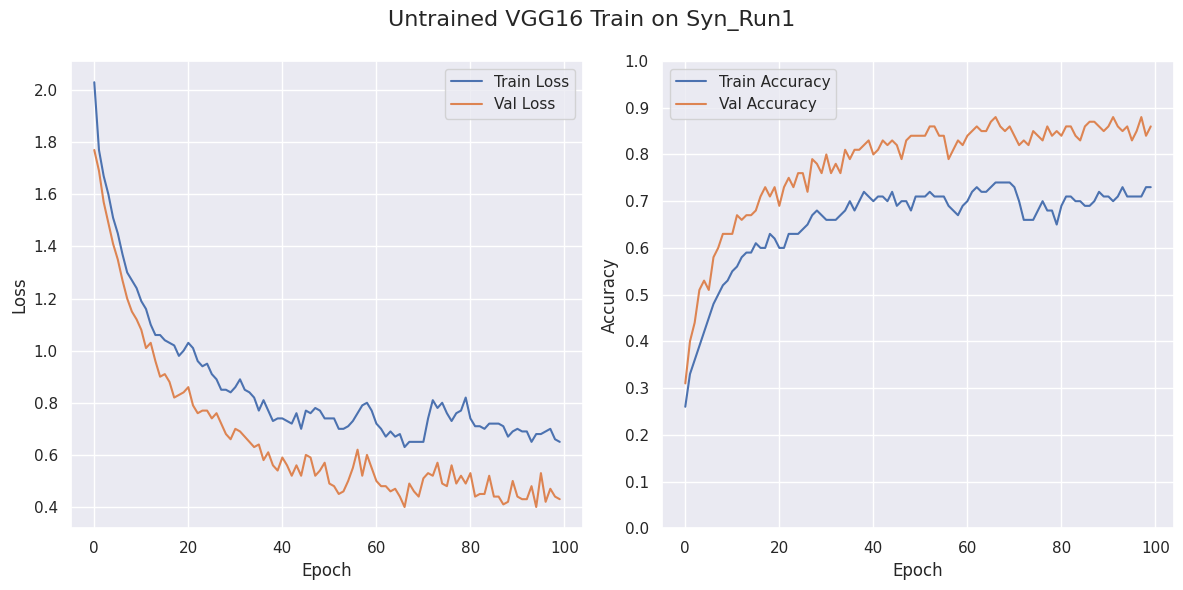

8/8 [==============================] - 2s 217ms/step
{'Test Loss': 1.0121, 'Test Accuracy': 0.6397, 'F1 Score': 0.61, 'Sensitivity (Recall)': 0.64, 'Precision': 0.66, 'Specificity (With Structural Pathology)': 0.94}


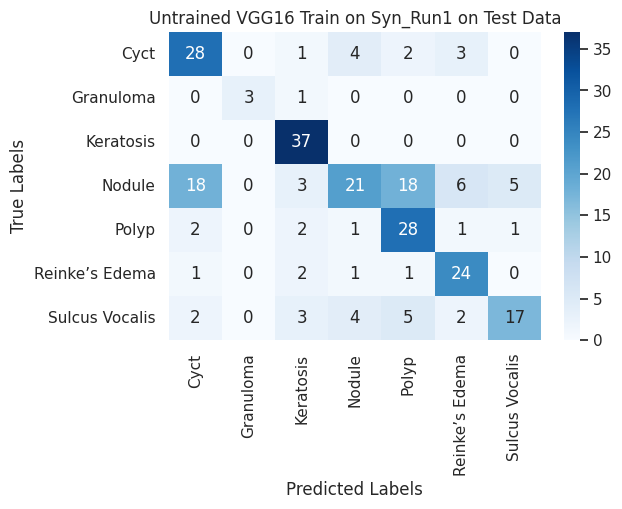

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
95/95 [==============================] - 29s 299ms/step - loss: 1.9434 - accuracy: 0.2757 - val_loss: 1.7442 - val_accuracy: 0.3605
Epoch 2/100
95/95 [==============================] - 28s 300ms/step - loss: 1.7060 - accuracy: 0.3422 - val_loss: 1.6469 - val_accuracy: 0.4053
Epoch 3/100
95/95 [==============================] - 28s 299ms/step - loss: 1.6264 - accuracy: 0.3880 - val_loss: 1.5678 - val_accuracy: 0.4395
Epoch 4/100
95/95 [==============================] - 28s 299ms/step - loss: 1.5721 - accuracy: 0.4051 - val_loss: 1.5042 - val_accuracy: 0.5000
Epoch 5/100
95/95 [==============================] - 29s 301ms/step - loss: 1.4823 - accuracy: 0.4384 - val_loss: 1.4521 - val_accuracy: 0.4961
Epoch 6/100
95/95 [==============================] - 28s 299ms/step - loss: 1.4276 - accuracy: 0.4667 - val_loss: 1.3459 - val_accuracy: 0.5211
Epoch 7/100
95/95 [============

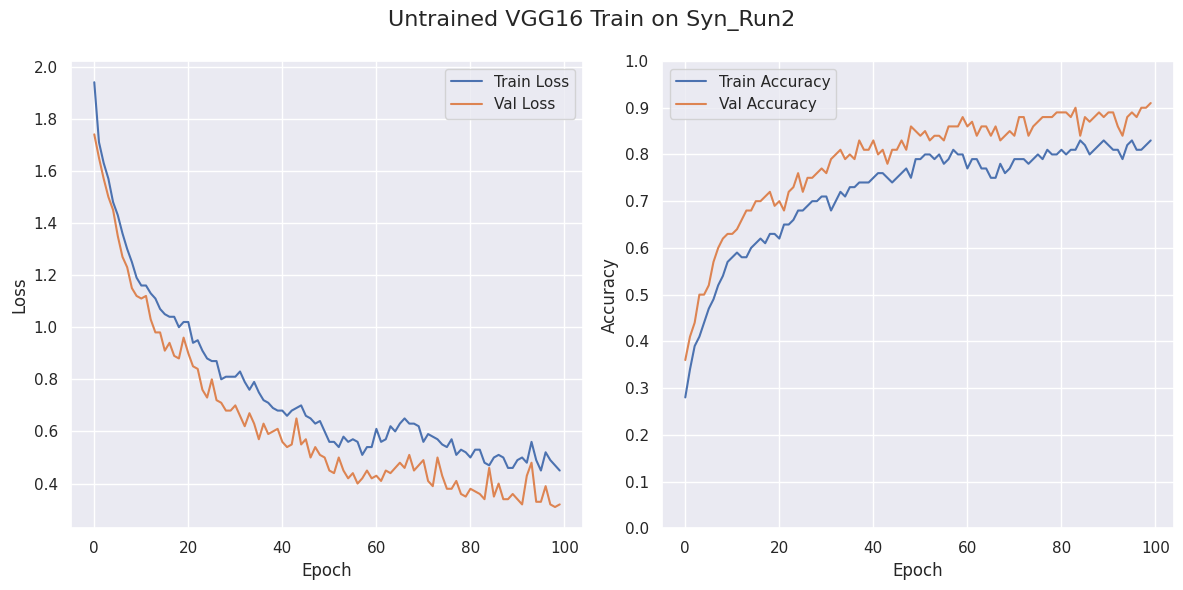

8/8 [==============================] - 2s 220ms/step
{'Test Loss': 0.9349, 'Test Accuracy': 0.7247, 'F1 Score': 0.71, 'Sensitivity (Recall)': 0.72, 'Precision': 0.77, 'Specificity (With Structural Pathology)': 0.95}


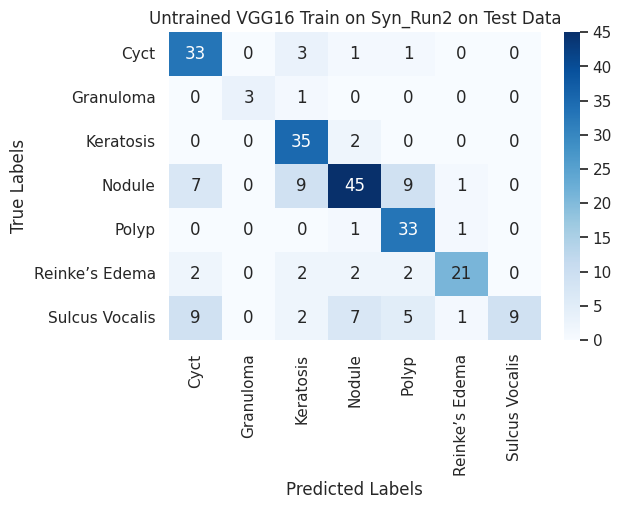

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
95/95 [==============================] - 29s 296ms/step - loss: 1.9325 - accuracy: 0.2628 - val_loss: 1.7531 - val_accuracy: 0.3316
Epoch 2/100
95/95 [==============================] - 28s 299ms/step - loss: 1.7162 - accuracy: 0.3340 - val_loss: 1.6217 - val_accuracy: 0.4224
Epoch 3/100
95/95 [==============================] - 28s 298ms/step - loss: 1.6108 - accuracy: 0.3729 - val_loss: 1.5162 - val_accuracy: 0.4250
Epoch 4/100
95/95 [==============================] - 28s 298ms/step - loss: 1.5176 - accuracy: 0.4275 - val_loss: 1.4185 - val_accuracy: 0.5342
Epoch 5/100
95/95 [==============================] - 28s 298ms/step - loss: 1.4367 - accuracy: 0.4674 - val_loss: 1.3443 - val_accuracy: 0.5658
Epoch 6/100
95/95 [==============================] - 28s 298ms/step - loss: 1.3452 - accuracy: 0.5000 - val_loss: 1.2346 - val_accuracy: 0.5934
Epoch 7/100
95/95 [============

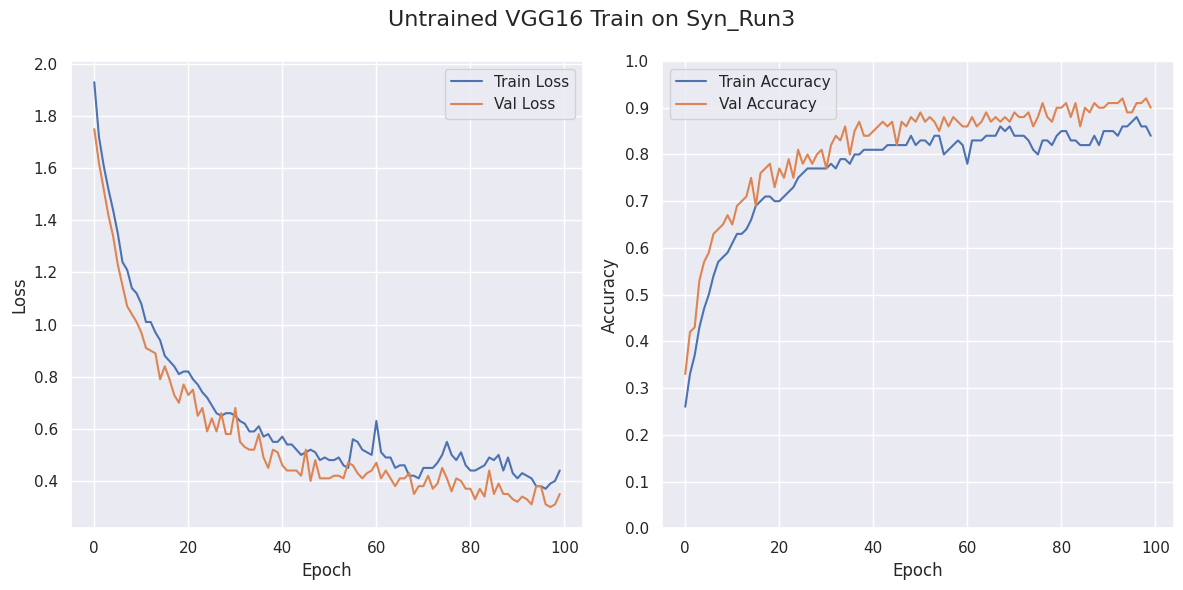

8/8 [==============================] - 2s 216ms/step
{'Test Loss': 1.0442, 'Test Accuracy': 0.6883, 'F1 Score': 0.68, 'Sensitivity (Recall)': 0.69, 'Precision': 0.78, 'Specificity (With Structural Pathology)': 0.95}


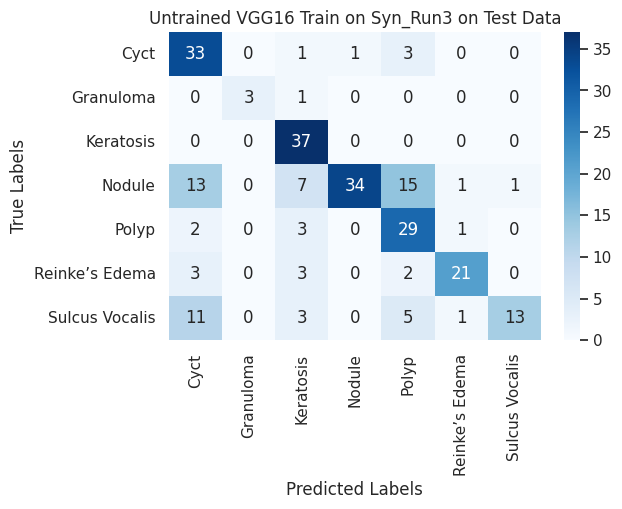

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
95/95 [==============================] - 29s 296ms/step - loss: 1.9680 - accuracy: 0.2684 - val_loss: 1.7516 - val_accuracy: 0.3645
Epoch 2/100
95/95 [==============================] - 28s 298ms/step - loss: 1.7119 - accuracy: 0.3337 - val_loss: 1.6522 - val_accuracy: 0.4184
Epoch 3/100
95/95 [==============================] - 28s 301ms/step - loss: 1.6376 - accuracy: 0.3603 - val_loss: 1.5780 - val_accuracy: 0.4079
Epoch 4/100
95/95 [==============================] - 29s 301ms/step - loss: 1.5620 - accuracy: 0.3821 - val_loss: 1.5067 - val_accuracy: 0.4750
Epoch 5/100
95/95 [==============================] - 28s 298ms/step - loss: 1.4963 - accuracy: 0.4203 - val_loss: 1.4438 - val_accuracy: 0.4750
Epoch 6/100
95/95 [==============================] - 28s 300ms/step - loss: 1.4427 - accuracy: 0.4351 - val_loss: 1.4106 - val_accuracy: 0.4829
Epoch 7/100
95/95 [============

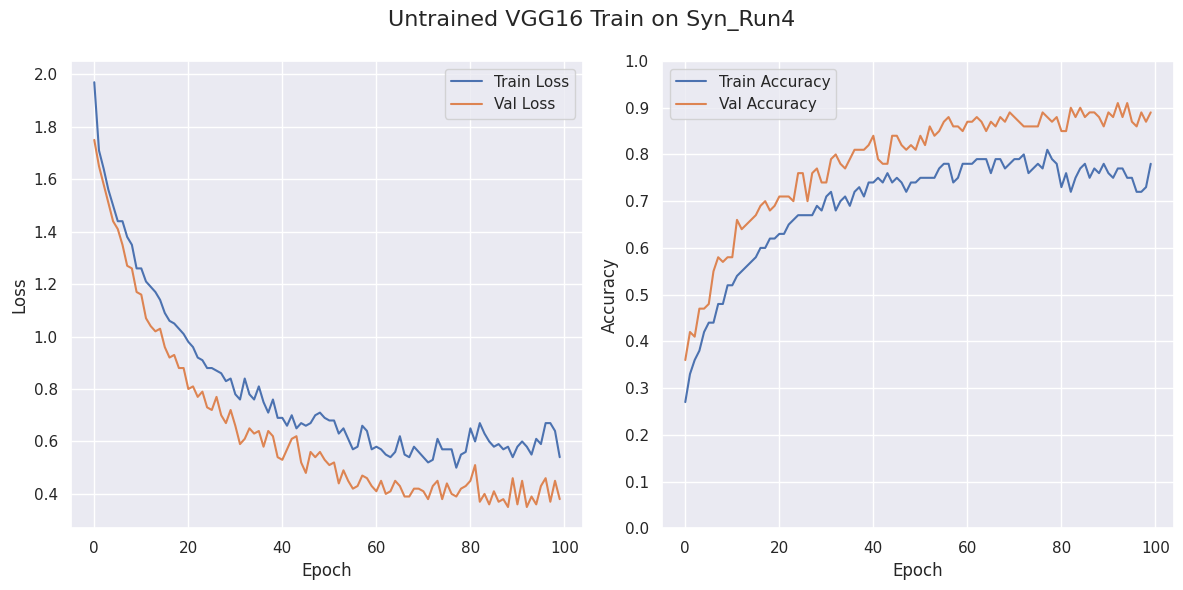

8/8 [==============================] - 2s 218ms/step
{'Test Loss': 0.8294, 'Test Accuracy': 0.749, 'F1 Score': 0.74, 'Sensitivity (Recall)': 0.75, 'Precision': 0.76, 'Specificity (With Structural Pathology)': 0.95}


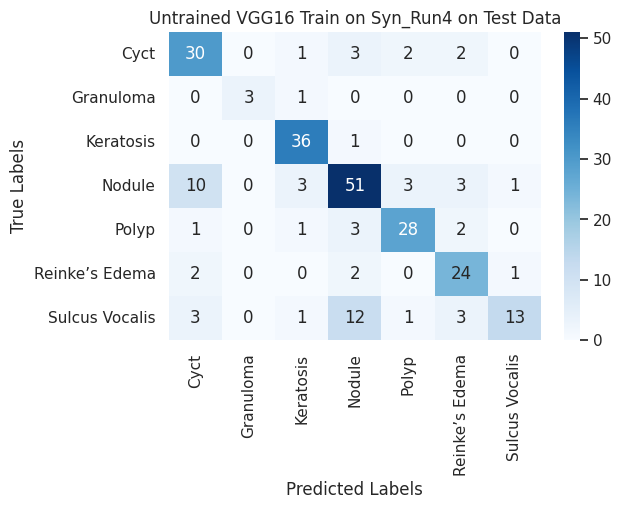

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
95/95 [==============================] - 29s 298ms/step - loss: 1.9633 - accuracy: 0.2635 - val_loss: 1.7650 - val_accuracy: 0.3329
Epoch 2/100
95/95 [==============================] - 28s 300ms/step - loss: 1.7225 - accuracy: 0.3327 - val_loss: 1.6634 - val_accuracy: 0.3697
Epoch 3/100
95/95 [==============================] - 28s 300ms/step - loss: 1.6573 - accuracy: 0.3603 - val_loss: 1.6232 - val_accuracy: 0.3421
Epoch 4/100
95/95 [==============================] - 28s 300ms/step - loss: 1.5879 - accuracy: 0.3837 - val_loss: 1.5511 - val_accuracy: 0.4395
Epoch 5/100
95/95 [==============================] - 29s 301ms/step - loss: 1.5433 - accuracy: 0.4005 - val_loss: 1.4831 - val_accuracy: 0.4566
Epoch 6/100
95/95 [==============================] - 28s 299ms/step - loss: 1.4901 - accuracy: 0.4292 - val_loss: 1.4112 - val_accuracy: 0.5092
Epoch 7/100
95/95 [============

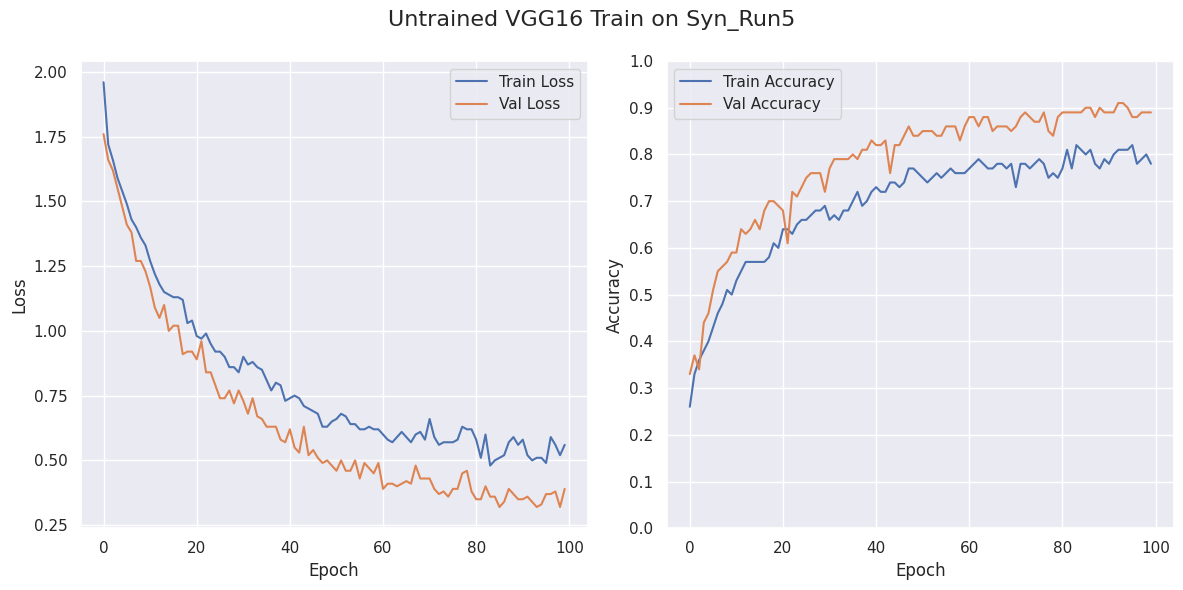

8/8 [==============================] - 2s 218ms/step
{'Test Loss': 1.0773, 'Test Accuracy': 0.6316, 'F1 Score': 0.6, 'Sensitivity (Recall)': 0.63, 'Precision': 0.74, 'Specificity (With Structural Pathology)': 0.94}


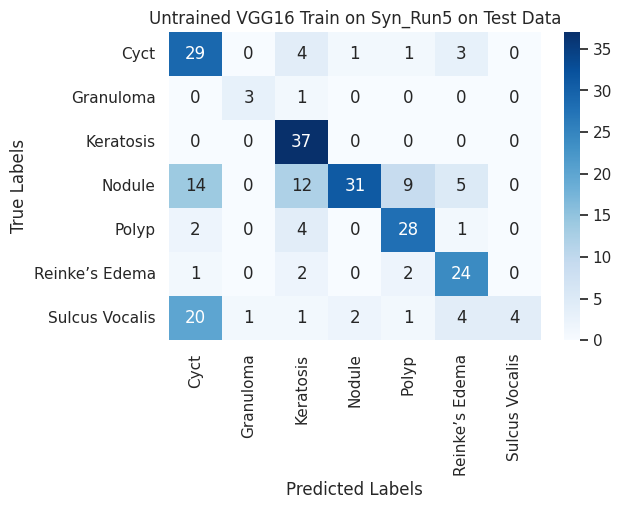

In [7]:
dataset_dir_org = f'{path_dir}/Original'
dataset_dir_ddpm = f'{path_dir}/Generated_CLEAN_1'

title = "Untrained VGG16 Train on Syn"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )

#### Train on Syn + 10 percent of Original Dataset

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
96/96 [==============================] - 29s 295ms/step - loss: 1.9514 - accuracy: 0.2599 - val_loss: 1.7240 - val_accuracy: 0.3059
Epoch 2/100
96/96 [==============================] - 28s 297ms/step - loss: 1.7302 - accuracy: 0.3364 - val_loss: 1.6758 - val_accuracy: 0.4118
Epoch 3/100
96/96 [==============================] - 29s 298ms/step - loss: 1.6558 - accuracy: 0.3652 - val_loss: 1.5517 - val_accuracy: 0.4510
Epoch 4/100
96/96 [==============================] - 29s 298ms/step - loss: 1.5568 - accuracy: 0.4103 - val_loss: 1.4918 - val_accuracy: 0.4340
Epoch 5/100
96/96 [==============================] - 28s 297ms/step - loss: 1.5110 - accuracy: 0.4305 - val_loss: 1.3867 - val_accuracy: 0.5386
Epoch 6/100
96/96 [==============================] - 28s 297ms/step - loss: 1.4031 - accuracy: 0.4727 - val_loss: 1.3132 - val_accuracy: 0.5856
Epoch 7/100
96/96 [============

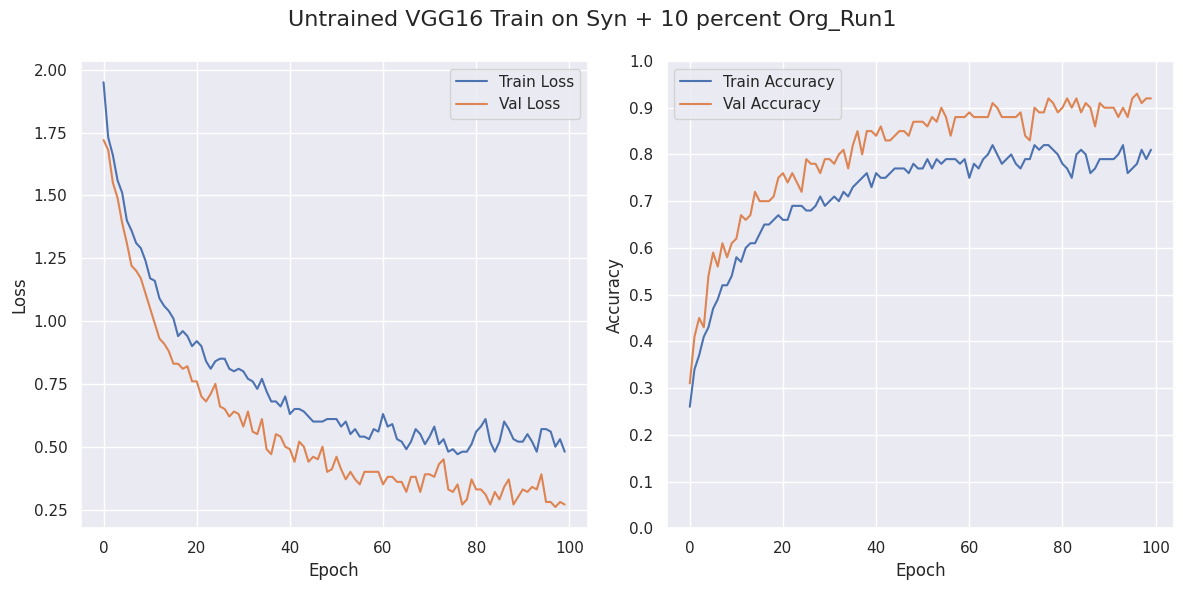

7/7 [==============================] - 2s 217ms/step
{'Test Loss': 0.8426, 'Test Accuracy': 0.7169, 'F1 Score': 0.7, 'Sensitivity (Recall)': 0.72, 'Precision': 0.77, 'Specificity (With Structural Pathology)': 0.95}


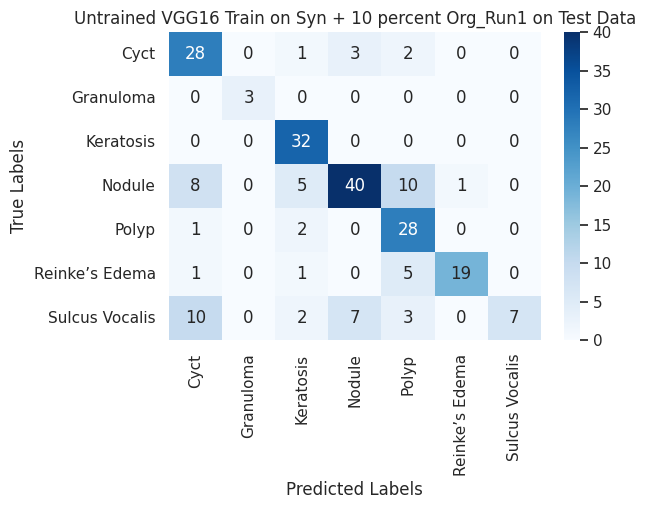

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
96/96 [==============================] - 29s 295ms/step - loss: 2.0727 - accuracy: 0.2563 - val_loss: 1.7562 - val_accuracy: 0.3307
Epoch 2/100
96/96 [==============================] - 29s 298ms/step - loss: 1.7422 - accuracy: 0.3259 - val_loss: 1.6750 - val_accuracy: 0.4222
Epoch 3/100
96/96 [==============================] - 29s 299ms/step - loss: 1.6789 - accuracy: 0.3563 - val_loss: 1.6148 - val_accuracy: 0.4458
Epoch 4/100
96/96 [==============================] - 29s 298ms/step - loss: 1.6227 - accuracy: 0.3707 - val_loss: 1.5759 - val_accuracy: 0.4196
Epoch 5/100
96/96 [==============================] - 28s 297ms/step - loss: 1.6156 - accuracy: 0.3710 - val_loss: 1.5637 - val_accuracy: 0.4327
Epoch 6/100
96/96 [==============================] - 28s 297ms/step - loss: 1.5886 - accuracy: 0.3851 - val_loss: 1.4783 - val_accuracy: 0.5085
Epoch 7/100
96/96 [============

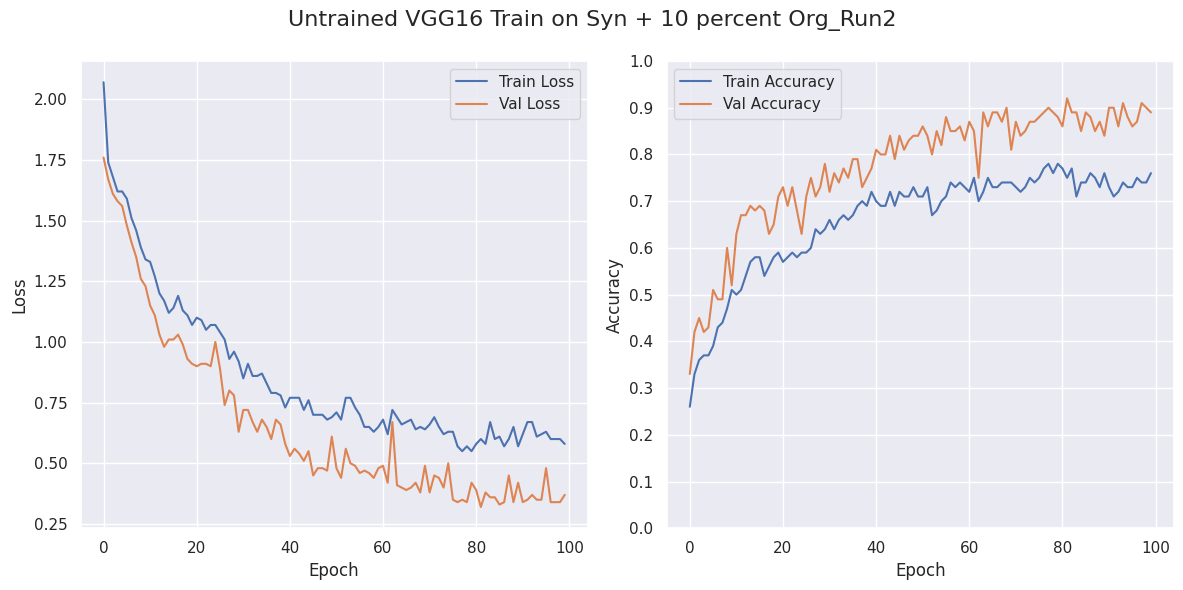

7/7 [==============================] - 2s 219ms/step
{'Test Loss': 1.0224, 'Test Accuracy': 0.6621, 'F1 Score': 0.65, 'Sensitivity (Recall)': 0.66, 'Precision': 0.71, 'Specificity (With Structural Pathology)': 0.94}


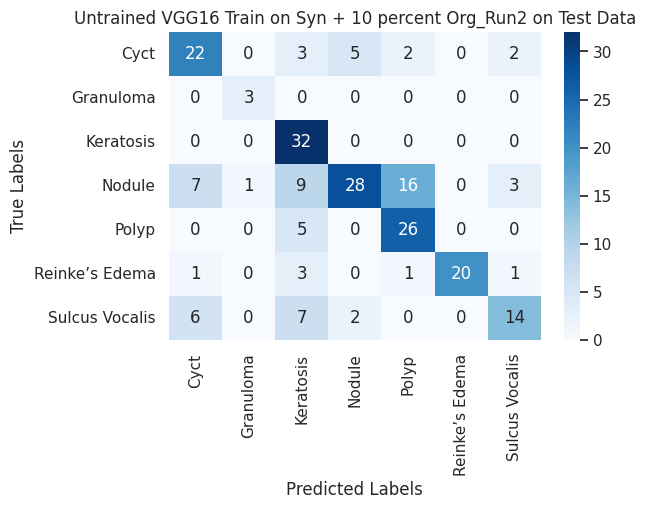

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
96/96 [==============================] - 29s 296ms/step - loss: 2.0207 - accuracy: 0.2690 - val_loss: 1.6873 - val_accuracy: 0.3137
Epoch 2/100
96/96 [==============================] - 29s 298ms/step - loss: 1.7149 - accuracy: 0.3200 - val_loss: 1.6073 - val_accuracy: 0.3908
Epoch 3/100
96/96 [==============================] - 29s 298ms/step - loss: 1.6407 - accuracy: 0.3717 - val_loss: 1.5065 - val_accuracy: 0.4261
Epoch 4/100
96/96 [==============================] - 29s 298ms/step - loss: 1.5553 - accuracy: 0.3913 - val_loss: 1.5592 - val_accuracy: 0.4366
Epoch 5/100
96/96 [==============================] - 28s 297ms/step - loss: 1.5372 - accuracy: 0.4126 - val_loss: 1.4284 - val_accuracy: 0.4967
Epoch 6/100
96/96 [==============================] - 28s 297ms/step - loss: 1.4793 - accuracy: 0.4367 - val_loss: 1.3718 - val_accuracy: 0.4954
Epoch 7/100
96/96 [============

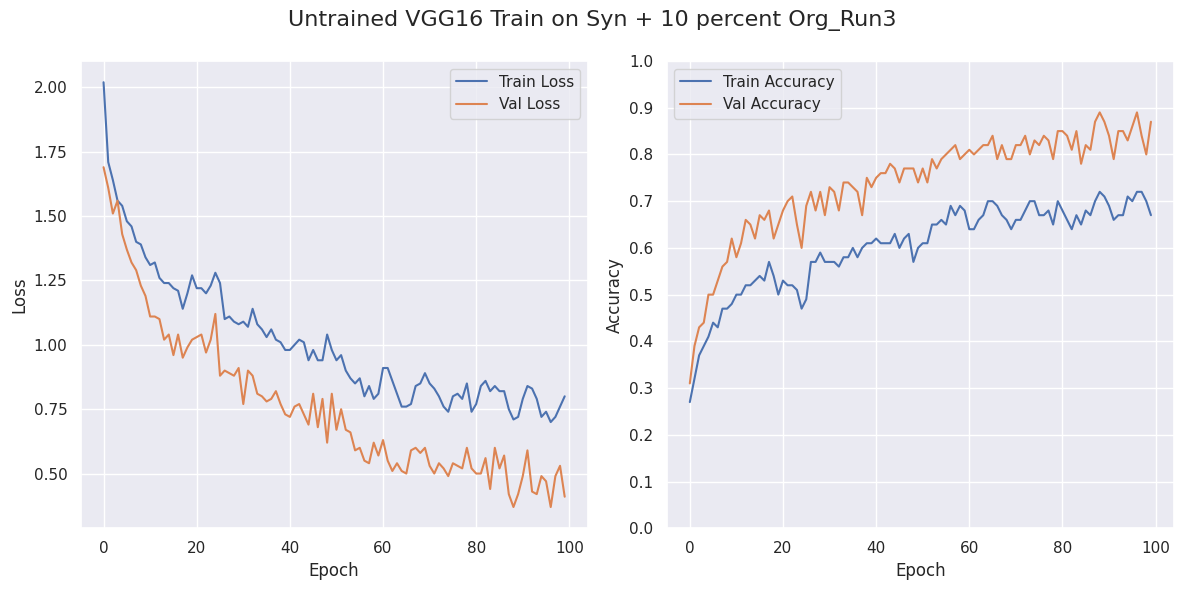

7/7 [==============================] - 2s 218ms/step
{'Test Loss': 1.0791, 'Test Accuracy': 0.6027, 'F1 Score': 0.58, 'Sensitivity (Recall)': 0.6, 'Precision': 0.63, 'Specificity (With Structural Pathology)': 0.93}


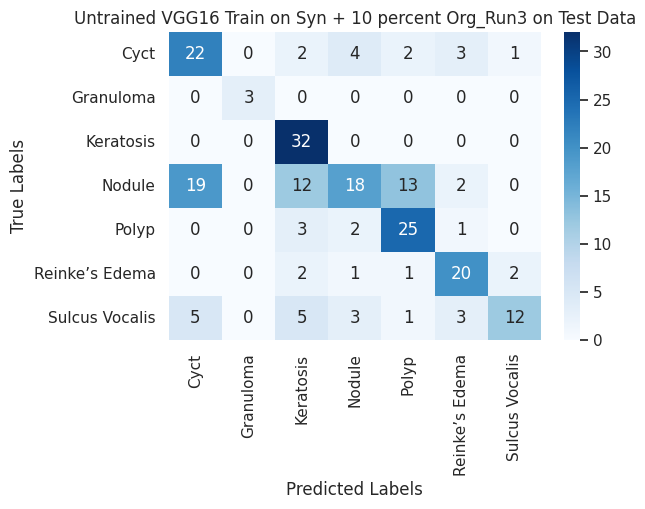

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
96/96 [==============================] - 29s 297ms/step - loss: 1.9101 - accuracy: 0.2854 - val_loss: 1.6869 - val_accuracy: 0.3647
Epoch 2/100
96/96 [==============================] - 28s 297ms/step - loss: 1.6983 - accuracy: 0.3432 - val_loss: 1.6386 - val_accuracy: 0.4144
Epoch 3/100
96/96 [==============================] - 28s 297ms/step - loss: 1.6167 - accuracy: 0.3884 - val_loss: 1.5433 - val_accuracy: 0.4706
Epoch 4/100
96/96 [==============================] - 28s 297ms/step - loss: 1.5664 - accuracy: 0.3962 - val_loss: 1.4610 - val_accuracy: 0.4497
Epoch 5/100
96/96 [==============================] - 28s 297ms/step - loss: 1.5139 - accuracy: 0.4207 - val_loss: 1.4063 - val_accuracy: 0.5412
Epoch 6/100
96/96 [==============================] - 28s 296ms/step - loss: 1.4769 - accuracy: 0.4443 - val_loss: 1.3742 - val_accuracy: 0.5634
Epoch 7/100
96/96 [============

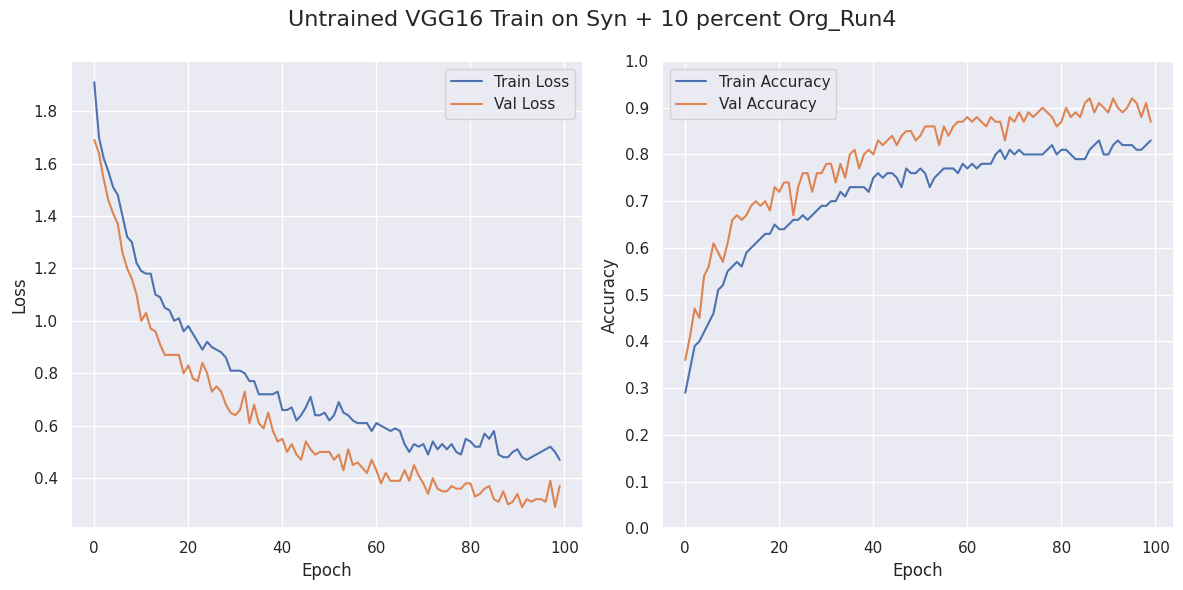

7/7 [==============================] - 2s 222ms/step
{'Test Loss': 1.2306, 'Test Accuracy': 0.6073, 'F1 Score': 0.57, 'Sensitivity (Recall)': 0.61, 'Precision': 0.73, 'Specificity (With Structural Pathology)': 0.93}


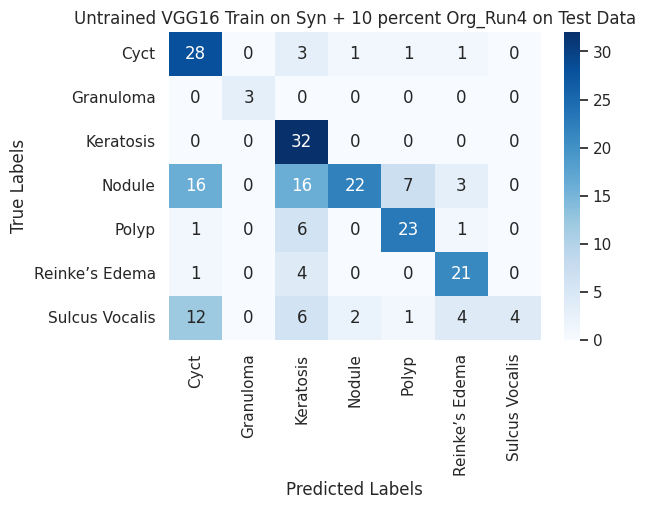

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
96/96 [==============================] - 29s 297ms/step - loss: 1.9509 - accuracy: 0.2632 - val_loss: 1.7205 - val_accuracy: 0.3242
Epoch 2/100
96/96 [==============================] - 29s 298ms/step - loss: 1.7323 - accuracy: 0.3298 - val_loss: 1.6748 - val_accuracy: 0.3908
Epoch 3/100
96/96 [==============================] - 29s 299ms/step - loss: 1.6679 - accuracy: 0.3472 - val_loss: 1.5842 - val_accuracy: 0.4078
Epoch 4/100
96/96 [==============================] - 29s 299ms/step - loss: 1.5979 - accuracy: 0.3828 - val_loss: 1.5440 - val_accuracy: 0.4196
Epoch 5/100
96/96 [==============================] - 29s 301ms/step - loss: 1.5495 - accuracy: 0.4145 - val_loss: 1.4968 - val_accuracy: 0.4758
Epoch 6/100
96/96 [==============================] - 29s 300ms/step - loss: 1.4795 - accuracy: 0.4469 - val_loss: 1.3967 - val_accuracy: 0.5608
Epoch 7/100
96/96 [============

In [ ]:
dataset_dir_org = f'{path_dir}/10_percent/Original'
dataset_dir_ddpm = f'{path_dir}/10_percent/Generated_CLEAN_1'

title = "Untrained VGG16 Train on Syn + 10 percent Org"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic_10percent_Original.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )

#### Train on Syn + 50 percent of Original Dataset

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']


2024-12-28 11:40:48.644400: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
98/98 [==============================] - 30s 301ms/step - loss: 1.9049 - accuracy: 0.2692 - val_loss: 1.6879 - val_accuracy: 0.3670
Epoch 2/100
98/98 [==============================] - 30s 304ms/step - loss: 1.6889 - accuracy: 0.3595 - val_loss: 1.5786 - val_accuracy: 0.3491
Epoch 3/100
98/98 [==============================] - 30s 305ms/step - loss: 1.5854 - accuracy: 0.3992 - val_loss: 1.4590 - val_accuracy: 0.5192
Epoch 4/100
98/98 [==============================] - 30s 305ms/step - loss: 1.4947 - accuracy: 0.4379 - val_loss: 1.3655 - val_accuracy: 0.5729
Epoch 5/100
98/98 [==============================] - 30s 305ms/step - loss: 1.3987 - accuracy: 0.4824 - val_loss: 1.2921 - val_accuracy: 0.6100
Epoch 6/100
98/98 [==============================] - 30s 305ms/step - loss: 1.3598 - accuracy: 0.5048 - val_loss: 1.2317 - val_accuracy: 0.6113
Epoch 7/100
98/98 [==============================] - 30s 307ms/step - loss: 1.2592 - accuracy: 0.5413 - val_loss: 1.1191 - val_accuracy:

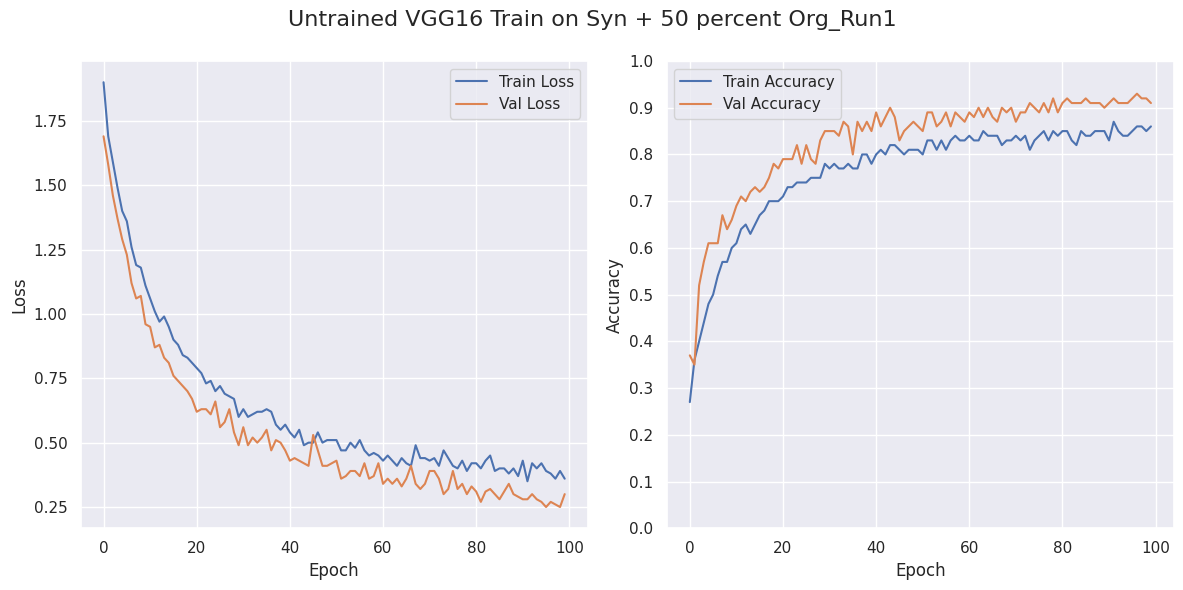

5/5 [==============================] - 1s 204ms/step
{'Test Loss': 0.6544, 'Test Accuracy': 0.7986, 'F1 Score': 0.79, 'Sensitivity (Recall)': 0.8, 'Precision': 0.81, 'Specificity (With Structural Pathology)': 0.96}


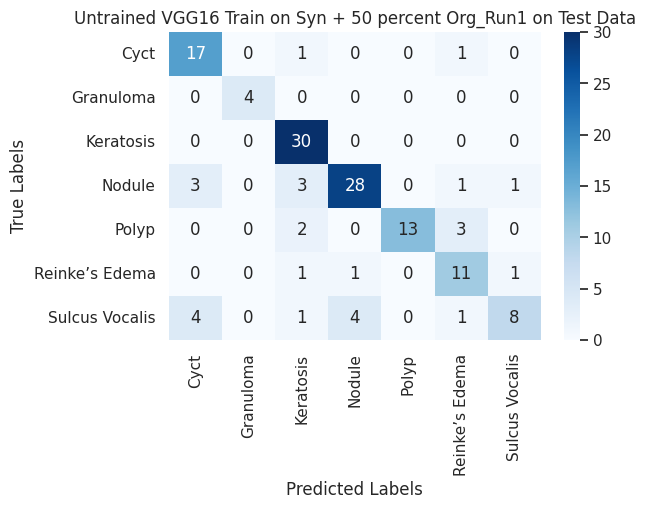

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
98/98 [==============================] - 30s 302ms/step - loss: 1.9998 - accuracy: 0.2622 - val_loss: 1.7248 - val_accuracy: 0.3197
Epoch 2/100
98/98 [==============================] - 30s 306ms/step - loss: 1.7873 - accuracy: 0.2980 - val_loss: 1.6781 - val_accuracy: 0.3248
Epoch 3/100
98/98 [==============================] - 30s 305ms/step - loss: 1.7112 - accuracy: 0.3364 - val_loss: 1.6136 - val_accuracy: 0.3939
Epoch 4/100
98/98 [==============================] - 30s 305ms/step - loss: 1.6520 - accuracy: 0.3473 - val_loss: 1.5753 - val_accuracy: 0.4872
Epoch 5/100
98/98 [==============================] - 30s 306ms/step - loss: 1.6198 - accuracy: 0.3732 - val_loss: 1.5464 - val_accuracy: 0.4847
Epoch 6/100
98/98 [==============================] - 30s 306ms/step - loss: 1.5727 - accuracy: 0.3931 - val_loss: 1.4519 - val_accuracy: 0.4770
Epoch 7/100
98/98 [============

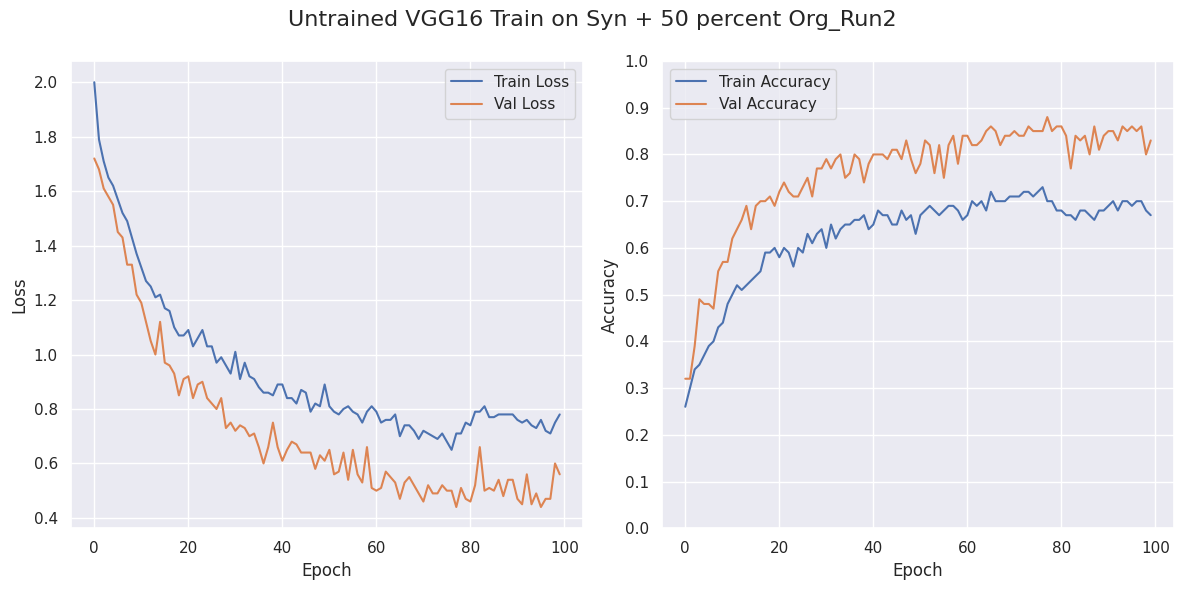

5/5 [==============================] - 1s 201ms/step
{'Test Loss': 1.1754, 'Test Accuracy': 0.6475, 'F1 Score': 0.63, 'Sensitivity (Recall)': 0.65, 'Precision': 0.71, 'Specificity (With Structural Pathology)': 0.94}


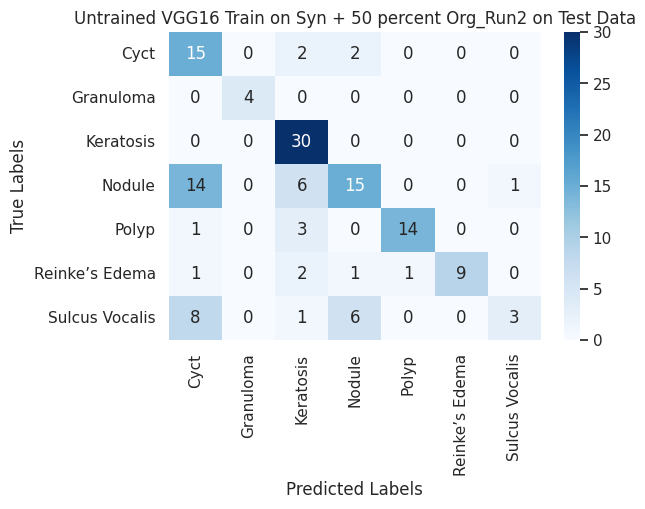

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
98/98 [==============================] - 30s 302ms/step - loss: 1.9159 - accuracy: 0.2695 - val_loss: 1.6915 - val_accuracy: 0.3363
Epoch 2/100
98/98 [==============================] - 30s 303ms/step - loss: 1.6809 - accuracy: 0.3672 - val_loss: 1.5728 - val_accuracy: 0.3862
Epoch 3/100
98/98 [==============================] - 30s 304ms/step - loss: 1.6005 - accuracy: 0.3928 - val_loss: 1.4817 - val_accuracy: 0.5192
Epoch 4/100
98/98 [==============================] - 30s 304ms/step - loss: 1.4878 - accuracy: 0.4462 - val_loss: 1.3521 - val_accuracy: 0.5512
Epoch 5/100
98/98 [==============================] - 30s 305ms/step - loss: 1.4194 - accuracy: 0.4846 - val_loss: 1.3165 - val_accuracy: 0.5601
Epoch 6/100
98/98 [==============================] - 30s 305ms/step - loss: 1.3612 - accuracy: 0.5026 - val_loss: 1.2014 - val_accuracy: 0.6215
Epoch 7/100
98/98 [============

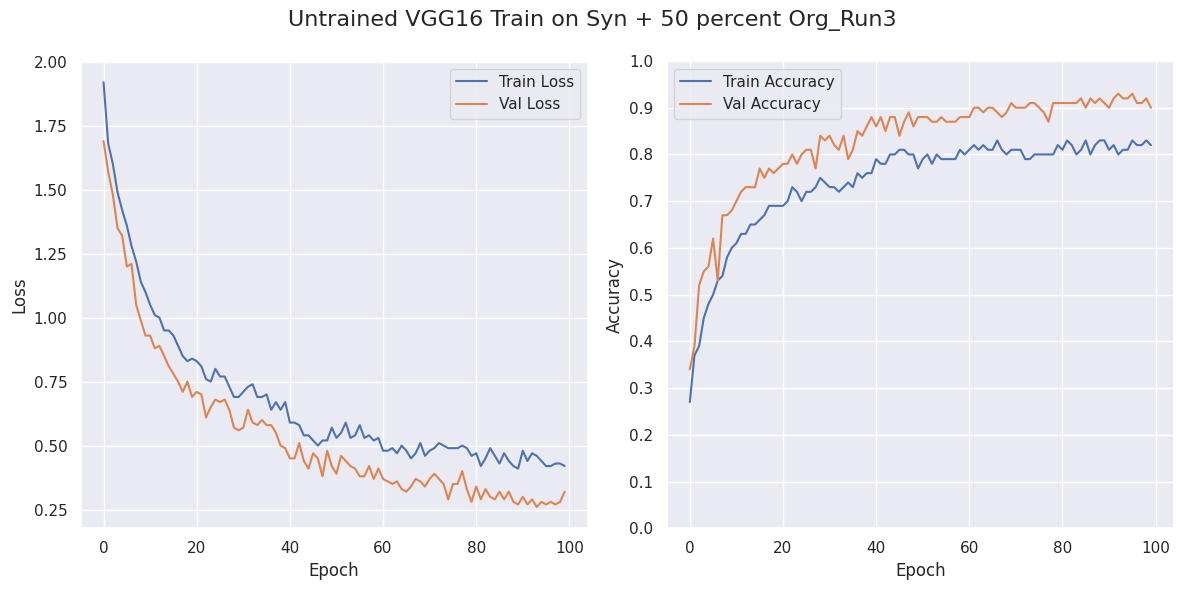

5/5 [==============================] - 1s 190ms/step
{'Test Loss': 0.7158, 'Test Accuracy': 0.7842, 'F1 Score': 0.77, 'Sensitivity (Recall)': 0.78, 'Precision': 0.82, 'Specificity (With Structural Pathology)': 0.96}


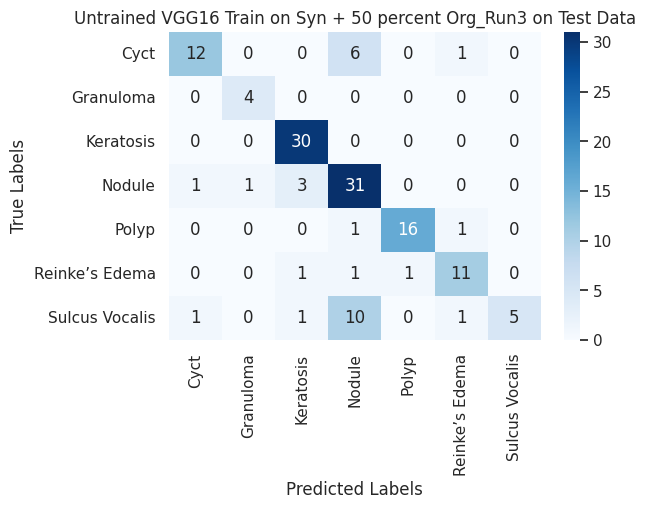

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
98/98 [==============================] - 31s 299ms/step - loss: 1.9202 - accuracy: 0.2692 - val_loss: 1.7298 - val_accuracy: 0.3095
Epoch 2/100
98/98 [==============================] - 29s 300ms/step - loss: 1.7299 - accuracy: 0.3361 - val_loss: 1.6225 - val_accuracy: 0.4488
Epoch 3/100
98/98 [==============================] - 29s 301ms/step - loss: 1.6096 - accuracy: 0.4004 - val_loss: 1.5080 - val_accuracy: 0.5051
Epoch 4/100
98/98 [==============================] - 29s 300ms/step - loss: 1.5188 - accuracy: 0.4385 - val_loss: 1.3939 - val_accuracy: 0.5588
Epoch 5/100
98/98 [==============================] - 29s 301ms/step - loss: 1.4327 - accuracy: 0.4741 - val_loss: 1.3908 - val_accuracy: 0.5013
Epoch 6/100
98/98 [==============================] - 29s 301ms/step - loss: 1.3702 - accuracy: 0.4875 - val_loss: 1.2589 - val_accuracy: 0.6049
Epoch 7/100
98/98 [============

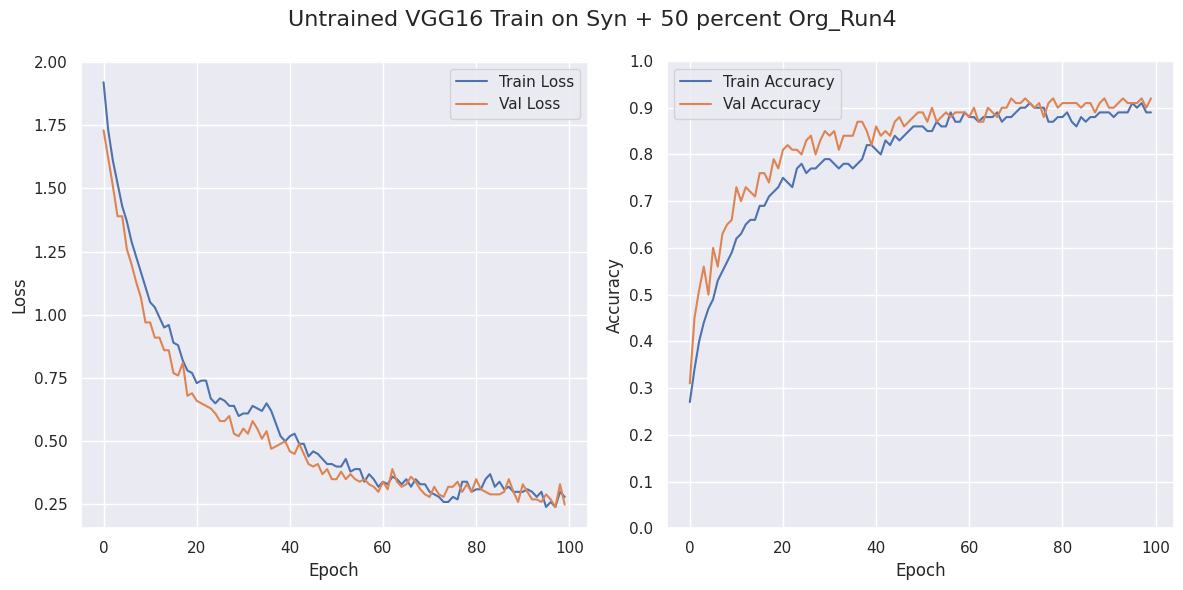

5/5 [==============================] - 1s 193ms/step
{'Test Loss': 0.5649, 'Test Accuracy': 0.8705, 'F1 Score': 0.87, 'Sensitivity (Recall)': 0.87, 'Precision': 0.88, 'Specificity (With Structural Pathology)': 0.98}


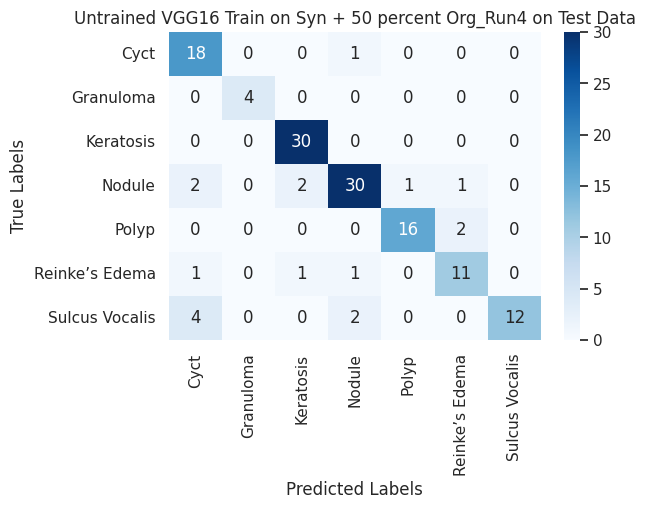

Class labels:  ['Cyct', 'Granuloma', 'Keratosis', 'Nodule', 'Polyp', 'Reinke’s Edema', 'Sulcus Vocalis']
Epoch 1/100
98/98 [==============================] - 30s 297ms/step - loss: 1.9721 - accuracy: 0.2612 - val_loss: 1.7033 - val_accuracy: 0.3555
Epoch 2/100
98/98 [==============================] - 29s 300ms/step - loss: 1.7334 - accuracy: 0.3351 - val_loss: 1.6165 - val_accuracy: 0.3568
Epoch 3/100
98/98 [==============================] - 29s 299ms/step - loss: 1.6600 - accuracy: 0.3659 - val_loss: 1.5548 - val_accuracy: 0.4719
Epoch 4/100
98/98 [==============================] - 29s 299ms/step - loss: 1.6131 - accuracy: 0.3755 - val_loss: 1.5203 - val_accuracy: 0.4527
Epoch 5/100
98/98 [==============================] - 29s 299ms/step - loss: 1.5555 - accuracy: 0.3982 - val_loss: 1.4128 - val_accuracy: 0.4821
Epoch 6/100
98/98 [==============================] - 29s 299ms/step - loss: 1.4736 - accuracy: 0.4357 - val_loss: 1.3735 - val_accuracy: 0.5294
Epoch 7/100
98/98 [============

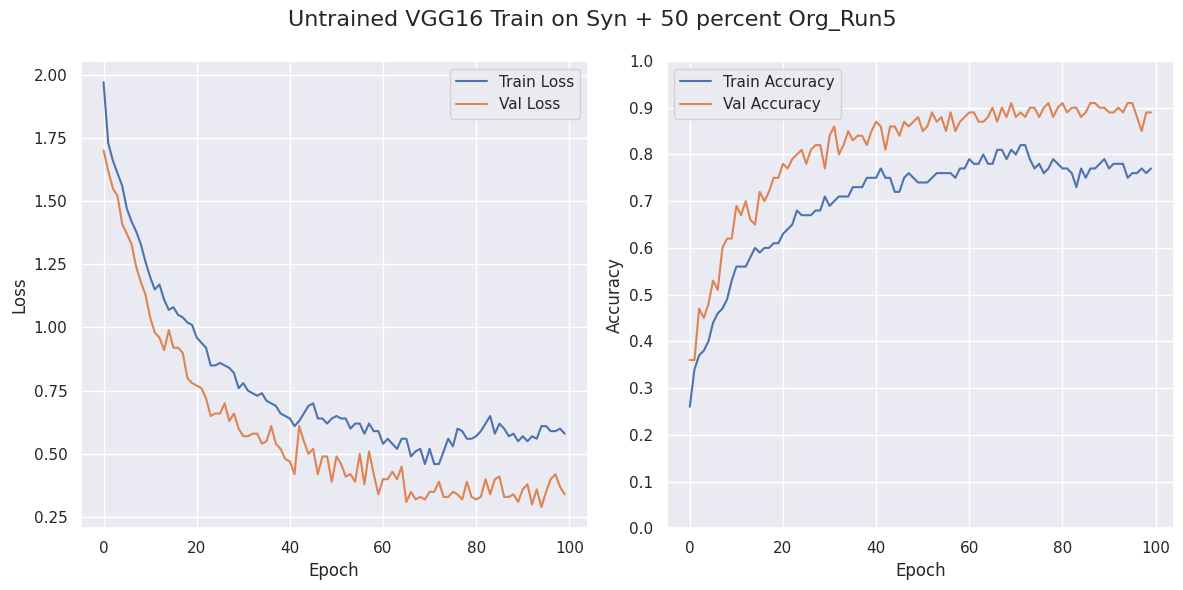

5/5 [==============================] - 1s 196ms/step
{'Test Loss': 0.6954, 'Test Accuracy': 0.7626, 'F1 Score': 0.76, 'Sensitivity (Recall)': 0.76, 'Precision': 0.79, 'Specificity (With Structural Pathology)': 0.96}


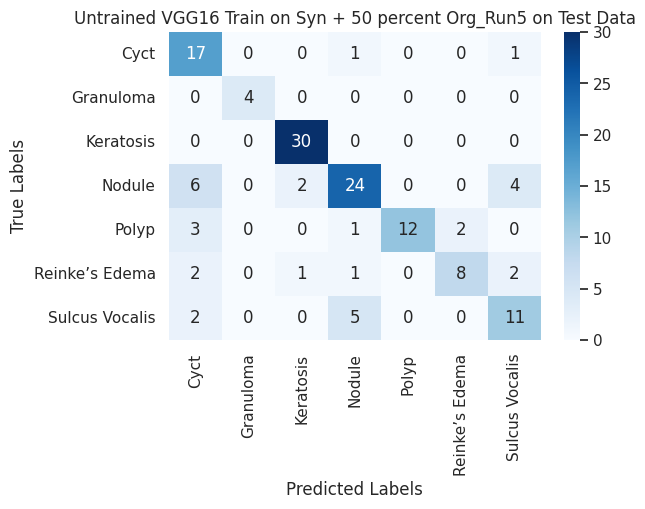

In [6]:
dataset_dir_org = f'{path_dir}/50_percent/Original'
dataset_dir_ddpm = f'{path_dir}/50_percent/Generated_CLEAN_1'

title = "Untrained VGG16 Train on Syn + 50 percent Org"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic_50percent_Original.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )